<a href="https://colab.research.google.com/github/Jenny5789/crop-image-classification/blob/main/notebooks/development/crop_classifier_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ===================================
# 4부: Keras vs PyTorch 비교
# ===================================

지금까지 Keras로 구현한 CNN 학습 과정을 PyTorch에서는 어떻게 구현하는지 비교하기 위해,
동일한 재분배 데이터와 CNN 구조를 사용하여 PyTorch 모델을 학습함.

가능한 한 동일한 데이터, 모델 구조, Optimizer, Loss, Epoch 조건을 사용하고,
Keras의 compile() / fit() 방식과 PyTorch의 직접 Training Loop 구현 방식,
그리고 두 프레임워크에서의 학습 결과를 비교함.

In [ ]:
import torch
print(torch.__version__)

2.8.0


In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

IMG_SIZE = 128
BATCH_SIZE = 32

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

train_dataset_pt = datasets.ImageFolder(
    r"C:\Users\AISW_203_103\Desktop\crop-classifier\data\reprocessed\train",
    transform=transform
)

val_dataset_pt = datasets.ImageFolder(
    r"C:\Users\AISW_203_103\Desktop\crop-classifier\data\reprocessed\val",
    transform=transform
)

train_loader_pt = DataLoader(
    train_dataset_pt,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader_pt = DataLoader(
    val_dataset_pt,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Train 이미지 수:", len(train_dataset_pt))
print("Validation 이미지 수:", len(val_dataset_pt))
print("클래스 목록:", train_dataset_pt.classes)
print("클래스 인덱스:", train_dataset_pt.class_to_idx)

Train 이미지 수: 1800
Validation 이미지 수: 450
클래스 목록: ['cabbage', 'cucumber', 'pepper']
클래스 인덱스: {'cabbage': 0, 'cucumber': 1, 'pepper': 2}


In [ ]:
class CropClassifierPT(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3)
        self.conv3 = nn.Conv2d(32, 32, kernel_size=3)
        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc1 = nn.Linear(32, 32)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(32, 3)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))
        x = self.gap(x)
        x = x.view(x.size(0), -1)   # (batch, 32, 1, 1) → (batch, 32)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)   # CrossEntropyLoss가 내부적으로 softmax 처리를 포함

model_pt = CropClassifierPT()
print(model_pt)

total_params = sum(p.numel() for p in model_pt.parameters())
print(f"총 파라미터: {total_params:,}개")

CropClassifierPT(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (gap): AdaptiveAvgPool2d(output_size=1)
  (fc1): Linear(in_features=32, out_features=32, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=32, out_features=3, bias=True)
)
총 파라미터: 15,491개


In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_pt.parameters())

print("Loss:", criterion)
print("Optimizer:", optimizer)

Loss: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [ ]:
import copy
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_pt = model_pt.to(device)

max_epochs = 50
patience = 7

best_val_loss = float("inf")
best_model_state = None
patience_count = 0

history_pt = {
    "accuracy": [],
    "val_accuracy": [],
    "loss": [],
    "val_loss": []
}

start_time = time.time()

for epoch in range(max_epochs):

    model_pt.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader_pt:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model_pt(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        train_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_loss /= train_total
    train_accuracy = train_correct / train_total

    model_pt.eval()

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader_pt:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model_pt(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss /= val_total
    val_accuracy = val_correct / val_total

    history_pt["accuracy"].append(train_accuracy)
    history_pt["val_accuracy"].append(val_accuracy)
    history_pt["loss"].append(train_loss)
    history_pt["val_loss"].append(val_loss)

    print(
        f"Epoch {epoch + 1}/{max_epochs} - "
        f"loss: {train_loss:.4f} - "
        f"accuracy: {train_accuracy:.4f} - "
        f"val_loss: {val_loss:.4f} - "
        f"val_accuracy: {val_accuracy:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model_pt.state_dict())
        patience_count = 0
    else:
        patience_count += 1

        if patience_count >= patience:
            print(f"EarlyStopping: Epoch {epoch + 1}에서 학습 종료")
            break

elapsed_pt = time.time() - start_time

model_pt.load_state_dict(best_model_state)

actual_epochs_pt = len(history_pt["loss"])

print(f"\n실제 학습 Epoch: {actual_epochs_pt}")
print(f"최저 Validation Loss: {best_val_loss:.4f}")
print(f"학습 시간: {elapsed_pt:.1f}초")
print(f"사용 Device: {device}")

Epoch 1/50 - loss: 1.0955 - accuracy: 0.3750 - val_loss: 1.0768 - val_accuracy: 0.5178
Epoch 2/50 - loss: 1.0218 - accuracy: 0.4539 - val_loss: 0.9260 - val_accuracy: 0.5578
Epoch 3/50 - loss: 0.9238 - accuracy: 0.5300 - val_loss: 0.8695 - val_accuracy: 0.5911
Epoch 4/50 - loss: 0.8699 - accuracy: 0.5778 - val_loss: 0.8263 - val_accuracy: 0.6133
Epoch 5/50 - loss: 0.8497 - accuracy: 0.6022 - val_loss: 0.8073 - val_accuracy: 0.6422
Epoch 6/50 - loss: 0.8491 - accuracy: 0.5994 - val_loss: 0.7815 - val_accuracy: 0.6178
Epoch 7/50 - loss: 0.8159 - accuracy: 0.6217 - val_loss: 0.7709 - val_accuracy: 0.6400
Epoch 8/50 - loss: 0.8115 - accuracy: 0.6283 - val_loss: 0.7534 - val_accuracy: 0.6644
Epoch 9/50 - loss: 0.7971 - accuracy: 0.6411 - val_loss: 0.7518 - val_accuracy: 0.6489
Epoch 10/50 - loss: 0.7768 - accuracy: 0.6350 - val_loss: 0.7467 - val_accuracy: 0.6578
Epoch 11/50 - loss: 0.7701 - accuracy: 0.6428 - val_loss: 0.7284 - val_accuracy: 0.6622
Epoch 12/50 - loss: 0.7761 - accuracy: 0.

In [ ]:
import os

save_dir = r"C:\Users\AISW_203_103\Desktop\crop-classifier\model"
os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(save_dir, "crop_classifier_pytorch_best.pth")

torch.save({
    "model_state_dict": model_pt.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "best_val_loss": best_val_loss,
    "actual_epochs": actual_epochs_pt,
    "history": history_pt,
    "img_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "class_to_idx": train_dataset_pt.class_to_idx,
    "device_used": str(device),
    "training_time_sec": elapsed_pt
}, save_path)

print("저장 완료:", save_path)

저장 완료: C:\Users\AISW_203_103\Desktop\crop-classifier\model\crop_classifier_pytorch_best.pth


### 실행 환경

- PyTorch: 2.8.0
- Device: CPU
- 입력 이미지: 128×128 RGB
- Batch Size: 32
- 데이터: `data/reprocessed`
- Train / Validation: 1,800 / 450

기존 GPU 환경에서는 학습 과정에서 커널이 종료되는 문제가 발생하여,
이번 비교 실험은 안정적으로 실행 가능한 CPU 환경에서 진행함.

따라서 Keras와 PyTorch의 학습 시간 차이는 프레임워크 자체의 속도 차이로 해석하지 않고,
각 실험의 실행 환경과 구현 방식이 포함된 측정값으로 기록함.

In [ ]:
checkpoint = torch.load(
    r"C:\Users\AISW_203_103\Desktop\crop-classifier\model\crop_classifier_pytorch_best.pth",
    map_location="cpu"
)

model_pt.load_state_dict(checkpoint["model_state_dict"])
model_pt.eval()

device = torch.device("cpu")
model_pt = model_pt.to(device)

print("저장 모델 불러오기 완료")
print("Best Validation Loss:", checkpoint["best_val_loss"])
print("학습 Epoch:", checkpoint["actual_epochs"])
print("학습 Device:", checkpoint["device_used"])
print("학습 시간(초):", checkpoint["training_time_sec"])

저장 모델 불러오기 완료
Best Validation Loss: 0.44473946541961695
학습 Epoch: 50
학습 Device: cpu
학습 시간(초): 19648.536000967026


In [ ]:
criterion = nn.CrossEntropyLoss()

In [ ]:
model_pt.eval()

train_loss_final = 0.0
train_correct_final = 0
train_total_final = 0

with torch.no_grad():
    for images, labels in train_loader_pt:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model_pt(images)
        loss = criterion(outputs, labels)

        train_loss_final += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)
        train_total_final += labels.size(0)
        train_correct_final += (predicted == labels).sum().item()

train_loss_final /= train_total_final
train_acc_final = train_correct_final / train_total_final


val_loss_final = 0.0
val_correct_final = 0
val_total_final = 0

with torch.no_grad():
    for images, labels in val_loader_pt:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model_pt(images)
        loss = criterion(outputs, labels)

        val_loss_final += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)
        val_total_final += labels.size(0)
        val_correct_final += (predicted == labels).sum().item()

val_loss_final /= val_total_final
val_acc_final = val_correct_final / val_total_final


print(f"복원 모델 Train Accuracy: {train_acc_final:.4f}")
print(f"복원 모델 Validation Accuracy: {val_acc_final:.4f}")
print(f"복원 모델 Train Loss: {train_loss_final:.4f}")
print(f"복원 모델 Validation Loss: {val_loss_final:.4f}")

복원 모델 Train Accuracy: 0.8339
복원 모델 Validation Accuracy: 0.8044
복원 모델 Train Loss: 0.4080
복원 모델 Validation Loss: 0.4447


## 비교 실험: Keras vs PyTorch

- Keras 실험 10에서 사용한 CNN 구조(Conv 16-32-32, GAP, Dense32, Dropout0.5)를 PyTorch로 다시 구현함
- PyTorch 모델의 총 파라미터 수는 15,491개로 Keras 모델과 동일함을 확인
- 동일한 재분배 데이터와 128×128 입력, Batch Size 32, Adam, 최대 50 Epoch 조건으로 학습함
- PyTorch에서는 마지막 출력층에 Softmax를 별도로 적용하지 않고 `CrossEntropyLoss`를 사용함

### 최종 결과 비교

| 항목 | Keras | PyTorch |
|---|---:|---:|
| 총 파라미터 | 15,491 | 15,491 |
| Train Accuracy | 0.8722 | 0.8339 |
| Validation Accuracy | 0.8644 | 0.8044 |
| Train Loss | 0.3048 | 0.4080 |
| Validation Loss | 0.3261 | 0.4447 |
| 실제 학습 Epoch | 50 | 50 |
| CPU 학습 시간 | 1,270.7초 (약 21분) | 19,648.5초 (약 5시간 27분) |

- PyTorch는 Validation Loss를 기준으로 가장 좋은 가중치를 복원했으며,
  최저 Validation Loss 0.4447은 Epoch 48에서 기록됨
- 이번 실행에서는 Keras의 Validation Accuracy가 PyTorch보다 약 6.0%p 높았고,
  Validation Loss도 더 낮았음
- CPU 학습 시간도 이번 실행에서는 Keras가 크게 짧았음
- 단, 초기 가중치, 데이터 셔플, 데이터 처리 방식, Training Loop 및 프레임워크 내부 최적화 등의 차이가 있으므로
  이번 결과만으로 Keras와 PyTorch 자체의 성능 및 속도 우위를 일반화하지 않음

### 코드 구조 차이

- Keras에서는 `compile()`과 `fit()`을 통해 학습 과정을 높은 수준에서 처리함
- PyTorch에서는 `optimizer.zero_grad()` → Forward → Loss 계산 → `loss.backward()` → `optimizer.step()`의 학습 과정을 직접 작성함
- Validation에서도 `model.eval()`과 `torch.no_grad()`를 직접 설정함
- 이를 통해 Keras에서 내부적으로 처리되던 순전파 → Loss 계산 → 역전파 → 가중치 업데이트 과정을 PyTorch 코드에서 직접 확인함

### 결론

Keras에서 사용한 CNN 구조를 PyTorch에서도 동일한 15,491개의 파라미터를 가진 모델로 구현함.
이번 실행에서는 Keras가 더 높은 Validation Accuracy와 더 낮은 Validation Loss를 보였으며,
CPU 학습 시간도 더 짧았음.

그러나 이번 비교는 두 프레임워크의 성능 우위를 판단하기 위한 벤치마크가 아니라,
동일한 CNN 구조를 서로 다른 프레임워크로 구현하면서 학습 과정의 차이를 이해하는 데 목적이 있음.
특히 PyTorch에서 Training Loop를 직접 구현하면서 순전파, Loss 계산, 역전파,
가중치 업데이트가 어떤 순서로 이루어지는지 코드 수준에서 확인함.

# ===================================
# 5부: 최종 모델
# ===================================

전체 실험 결과를 비교한 결과, 재분배 데이터를 사용한 실험 10의 Keras CNN을
최종 모델로 선택함.

- 모델 구조: Conv 16-32-32 → GAP → Dense32 → Dropout 0.5
- 총 파라미터: 15,491개
- Train Accuracy: 87.22%
- Validation Accuracy: 86.44%
- Train Loss: 0.3048
- Validation Loss: 0.3261
- 실제 학습 Epoch: 50

추가 단순화 모델(실험 11)과 PyTorch로 동일 구조를 구현한 비교 실험보다
이번 실험 조건에서 더 높은 Validation Accuracy와 더 낮은 Validation Loss를 보였기 때문에
실험 10의 Keras CNN을 최종 모델로 선택함.

최종 모델은 `model/crop_classifier_final_600.keras`로 저장함.

# ===================================
# 6부: 예측 테스트
# ===================================

저장된 최종 모델을 불러와 실제 이미지에 대한 예측이 정상적으로
수행되는지 확인함.

모델이 예측한 클래스와 확신도(Confidence)를 이미지와 함께 시각화하여,
학습된 모델이 실제 이미지에 대해 어떻게 예측하는지 확인함.

In [ ]:
from tensorflow import keras

loaded_model = keras.models.load_model(
    r"C:\Users\AISW_203_103\Desktop\crop-classifier\model\crop_classifier_final_600.keras"
)

loaded_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)              │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 126, 126, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 63, 63, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 61, 61, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 30, 30, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 28, 28, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_2           │ (None, 32)                  │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 3)                   │              99 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 46,475 (181.55 KB)

 Trainable params: 15,491 (60.51 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 30,984 (121.04 KB)

In [ ]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

class_names = ['cabbage', 'cucumber', 'pepper']
class_names_kor = {'cabbage': '배추', 'cucumber': '오이', 'pepper': '고추'}

def predict_image(image_path, model):
    img = Image.open(image_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    img_array = np.array(img)
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array, verbose=0)
    predicted_idx = np.argmax(prediction)
    predicted_class = class_names_kor[class_names[predicted_idx]]
    confidence = np.max(prediction) * 100

    plt.imshow(img)
    plt.title(f"예측: {predicted_class} ({confidence:.1f}%)")
    plt.axis('off')
    plt.show()

    return predicted_class, confidence

In [ ]:
import os

base_dir = r"C:\Users\AISW_203_103\Desktop\crop-classifier\data\prediction_test"

for class_name in ["cabbage", "cucumber", "pepper"]:
    os.makedirs(os.path.join(base_dir, class_name), exist_ok=True)

print("예측 테스트 폴더 생성 완료")

예측 테스트 폴더 생성 완료


선택된 이미지: V006_79_0_00_01_01_13_0_a05_20201111_0106_S01_1.JPG


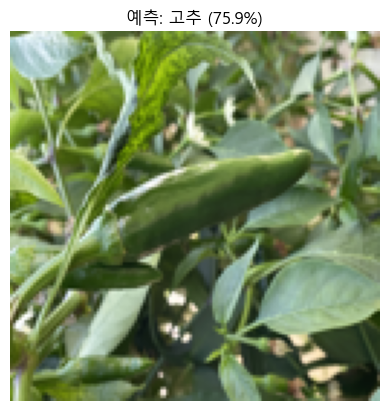

('고추', np.float32(75.94554))

In [ ]:
import os
import random

test_folder = r"C:\Users\AISW_203_103\Desktop\crop-classifier\data\prediction_test\pepper"

sample_file = random.choice(os.listdir(test_folder))

print("선택된 이미지:", sample_file)

predict_image(
    os.path.join(test_folder, sample_file),
    loaded_model
)

선택된 이미지: V006_79_0_00_03_03_11_0_c28_20201204_0006_S01_1.jpg


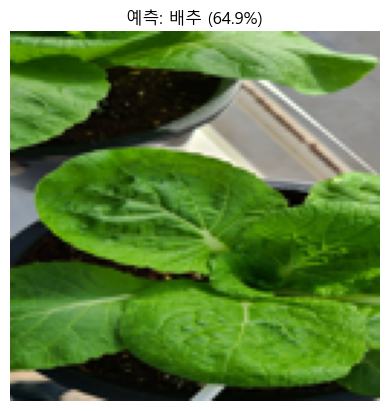

('배추', np.float32(64.90204))

In [ ]:
# 배추 테스트
test_folder_cabbage = r"C:\Users\AISW_203_103\Desktop\crop-classifier\data\prediction_test\cabbage"

sample_file = random.choice(os.listdir(test_folder_cabbage))

print("선택된 이미지:", sample_file)

predict_image(
    os.path.join(test_folder_cabbage, sample_file),
    loaded_model
)

선택된 이미지: V006_79_0_00_06_01_13_0_b02_20201015_0051_S01_1.jpg


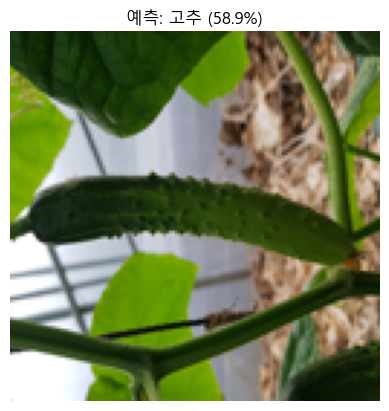

('고추', np.float32(58.87307))

In [ ]:
# 오이 테스트
test_folder_cucumber = r"C:\Users\AISW_203_103\Desktop\crop-classifier\data\prediction_test\cucumber"

sample_file = random.choice(os.listdir(test_folder_cucumber))

print("선택된 이미지:", sample_file)

predict_image(
    os.path.join(test_folder_cucumber, sample_file),
    loaded_model
)

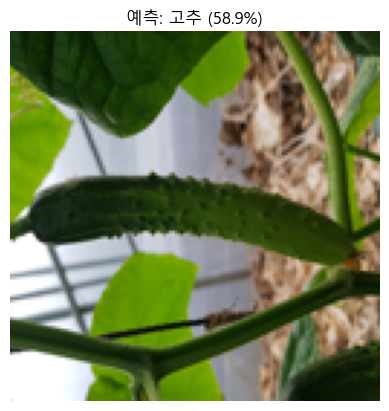

('고추', np.float32(58.87307))

In [ ]:
sample_file = "V006_79_0_00_06_01_13_0_b02_20201015_0051_S01_1.jpg"

predict_image(
    os.path.join(test_folder_cucumber, sample_file),
    loaded_model
)

In [ ]:
def predict_image_detail(image_path, model):
    img = tf.keras.utils.load_img(
        image_path,
        target_size=(IMG_SIZE, IMG_SIZE)
    )

    img_array = tf.keras.utils.img_to_array(img)
    input_array = tf.expand_dims(img_array, axis=0)

    prediction = model.predict(input_array, verbose=0)[0]

    for i, class_name in enumerate(class_names):
        print(
            f"{class_names_kor[class_name]}: "
            f"{prediction[i] * 100:.2f}%"
        )

    predicted_idx = np.argmax(prediction)
    predicted_class = class_names_kor[class_names[predicted_idx]]

    plt.imshow(img)
    plt.title(
        f"예측: {predicted_class} "
        f"({prediction[predicted_idx] * 100:.1f}%)"
    )
    plt.axis('off')
    plt.show()

In [ ]:
import tensorflow as tf

배추: 0.30%
오이: 41.49%
고추: 58.21%


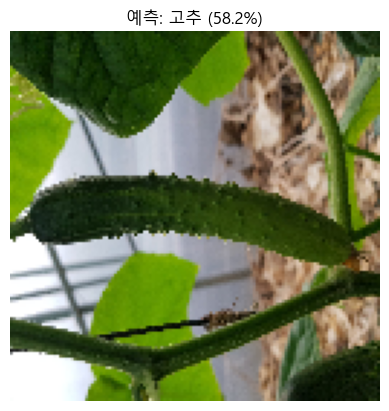

In [ ]:
sample_file = "V006_79_0_00_06_01_13_0_b02_20201015_0051_S01_1.jpg"

predict_image_detail(
    os.path.join(test_folder_cucumber, sample_file),
    loaded_model
)

In [ ]:
val_ds = keras.utils.image_dataset_from_directory(
    r"C:\Users\AISW_203_103\Desktop\crop-classifier\data\reprocessed\val",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=False
)

print("클래스 목록:", val_ds.class_names)

Found 450 files belonging to 3 classes.
클래스 목록: ['cabbage', 'cucumber', 'pepper']


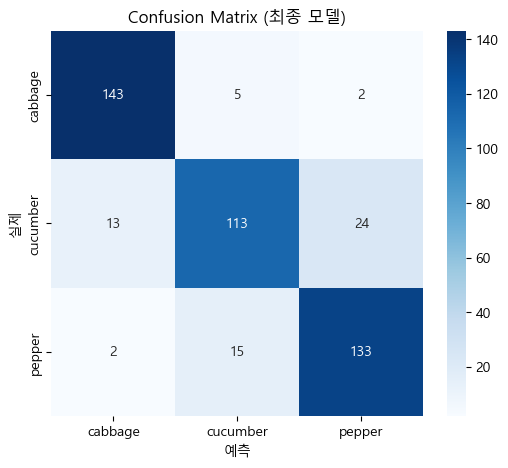

              precision    recall  f1-score   support

     cabbage       0.91      0.95      0.93       150
    cucumber       0.85      0.75      0.80       150
      pepper       0.84      0.89      0.86       150

    accuracy                           0.86       450
   macro avg       0.86      0.86      0.86       450
weighted avg       0.86      0.86      0.86       450



In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = loaded_model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

cm = confusion_matrix(y_true, y_pred)

class_names_list = ['cabbage', 'cucumber', 'pepper']

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_names_list,
    yticklabels=class_names_list,
    cmap='Blues'
)

plt.xlabel('예측')
plt.ylabel('실제')
plt.title('Confusion Matrix (최종 모델)')
plt.show()

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names_list
    )
)

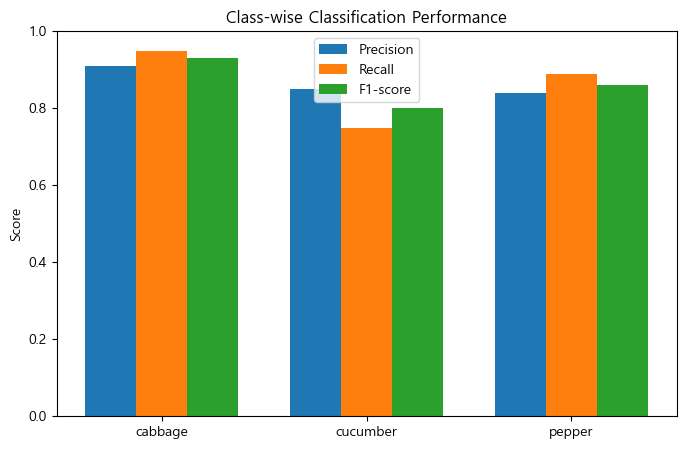

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

classes = ['cabbage', 'cucumber', 'pepper']

precision = [0.91, 0.85, 0.84]
recall = [0.95, 0.75, 0.89]
f1_score = [0.93, 0.80, 0.86]

x = np.arange(len(classes))
width = 0.25

plt.figure(figsize=(8, 5))

plt.bar(x - width, precision, width, label='Precision')
plt.bar(x, recall, width, label='Recall')
plt.bar(x + width, f1_score, width, label='F1-score')

plt.xticks(x, classes)
plt.ylim(0, 1.0)
plt.ylabel('Score')
plt.title('Class-wise Classification Performance')
plt.legend()

plt.show()

## Confusion Matrix 종합 해석 (최종 모델 기준)

- 전체 정확도(Accuracy): 86.44% (389 / 450)

- 클래스별 Recall:
  - cabbage: 0.95
  - cucumber: 0.75
  - pepper: 0.89
  - cabbage의 Recall이 가장 높았고, cucumber가 가장 낮게 나타남

- 가장 빈번한 오분류는 cucumber → pepper 24건으로 나타남
- 반대 방향인 pepper → cucumber도 15건 발생하여 cucumber와 pepper 사이에서 양방향 혼동이 확인됨

- cabbage는 실제 150장 중 143장을 정확하게 분류하여 가장 높은 Recall(0.95)을 보임
  - cucumber로 5장, pepper로 2장 오분류됨
  - Precision 0.91, Recall 0.95, F1-score 0.93

- cucumber는 실제 150장 중 113장을 정확하게 분류함
  - cabbage로 13장, pepper로 24장 오분류됨
  - Recall이 0.75로 세 클래스 중 가장 낮아 실제 cucumber 이미지를 다른 클래스로 놓치는 경우가 상대적으로 많았음
  - Precision 0.85, Recall 0.75, F1-score 0.80

- pepper는 실제 150장 중 133장을 정확하게 분류함
  - cabbage로 2장, cucumber로 15장 오분류됨
  - Precision 0.84, Recall 0.89, F1-score 0.86

- 앞선 개별 예측 테스트에서도 실제 cucumber 이미지를 pepper로 예측한 사례가 확인되었으며,
  전체 Validation 데이터에서도 cucumber → pepper가 24건으로 가장 큰 단일 오분류 패턴으로 나타남

- 결론:
  전체 Validation Accuracy는 86.44%였지만 클래스별 성능에는 차이가 있었으며,
  특히 cucumber의 Recall이 가장 낮고 cucumber와 pepper 사이의 혼동이 상대적으로 크게 나타남

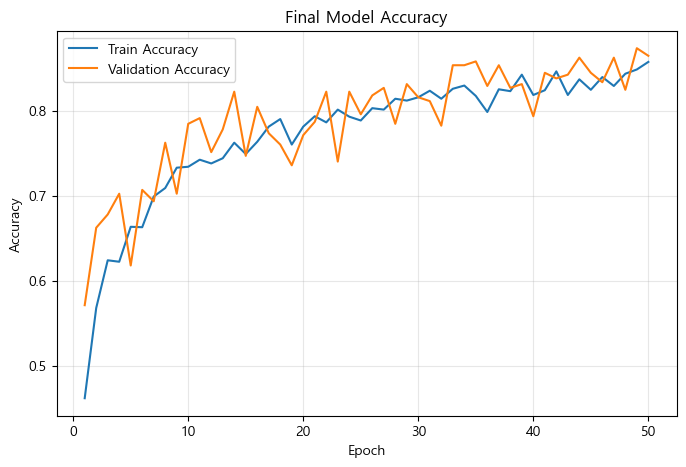

In [ ]:
import matplotlib.pyplot as plt

epochs = list(range(1, 51))

train_acc = [
    0.4617, 0.5678, 0.6239, 0.6222, 0.6633, 0.6628, 0.6989, 0.7089, 0.7328, 0.7339,
    0.7422, 0.7378, 0.7439, 0.7622, 0.7489, 0.7633, 0.7811, 0.7900, 0.7600, 0.7811,
    0.7933, 0.7861, 0.8011, 0.7928, 0.7883, 0.8028, 0.8011, 0.8139, 0.8117, 0.8156,
    0.8233, 0.8139, 0.8256, 0.8294, 0.8172, 0.7983, 0.8250, 0.8228, 0.8422, 0.8183,
    0.8239, 0.8461, 0.8183, 0.8367, 0.8244, 0.8394, 0.8289, 0.8433, 0.8483, 0.8572
]

val_acc = [
    0.5711, 0.6622, 0.6778, 0.7022, 0.6178, 0.7067, 0.6933, 0.7622, 0.7022, 0.7844,
    0.7911, 0.7511, 0.7778, 0.8222, 0.7467, 0.8044, 0.7733, 0.7600, 0.7356, 0.7711,
    0.7867, 0.8222, 0.7400, 0.8222, 0.7956, 0.8178, 0.8267, 0.7844, 0.8311, 0.8156,
    0.8111, 0.7822, 0.8533, 0.8533, 0.8578, 0.8289, 0.8533, 0.8267, 0.8311, 0.7933,
    0.8444, 0.8378, 0.8422, 0.8622, 0.8444, 0.8333, 0.8622, 0.8244, 0.8733, 0.8644
]

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_acc, label='Train Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Final Model Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

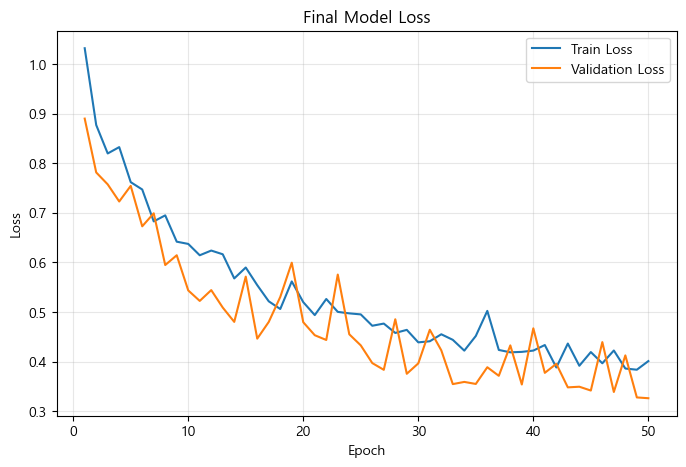

In [ ]:
train_loss = [
    1.0322, 0.8773, 0.8199, 0.8327, 0.7620, 0.7472, 0.6828, 0.6950, 0.6419, 0.6374,
    0.6145, 0.6240, 0.6165, 0.5678, 0.5898, 0.5542, 0.5216, 0.5061, 0.5617, 0.5199,
    0.4938, 0.5263, 0.5003, 0.4973, 0.4952, 0.4723, 0.4767, 0.4578, 0.4640, 0.4388,
    0.4410, 0.4551, 0.4439, 0.4221, 0.4517, 0.5023, 0.4235, 0.4187, 0.4196, 0.4222,
    0.4334, 0.3881, 0.4364, 0.3916, 0.4192, 0.3966, 0.4224, 0.3860, 0.3836, 0.4010
]

val_loss = [
    0.8902, 0.7816, 0.7575, 0.7230, 0.7545, 0.6729, 0.6992, 0.5948, 0.6145, 0.5436,
    0.5224, 0.5442, 0.5090, 0.4801, 0.5714, 0.4463, 0.4800, 0.5304, 0.5995, 0.4794,
    0.4532, 0.4436, 0.5756, 0.4551, 0.4327, 0.3970, 0.3834, 0.4854, 0.3754, 0.3964,
    0.4642, 0.4227, 0.3546, 0.3590, 0.3549, 0.3886, 0.3713, 0.4327, 0.3538, 0.4671,
    0.3773, 0.3955, 0.3480, 0.3493, 0.3416, 0.4393, 0.3387, 0.4125, 0.3277, 0.3261
]

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, label='Train Loss')
plt.plot(epochs, val_loss, label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Final Model Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 최종 모델 학습 곡선 해석

- Train Accuracy와 Validation Accuracy가 학습이 진행될수록 전반적으로 함께 상승함
- Validation Accuracy는 일부 Epoch에서 변동이 있었지만 후반부에 0.85 이상까지 상승했으며,
  학습 중 최고 Validation Accuracy는 Epoch 49의 0.8733으로 나타남
- Train Loss와 Validation Loss도 전체적으로 감소하는 흐름을 보였음
- Validation Loss는 학습 후반까지 계속 개선되어 Epoch 50에서 0.3261로 가장 낮게 나타남
- EarlyStopping은 Validation Loss를 기준으로 설정했지만,
  후반부까지 Validation Loss가 갱신되어 50 Epoch까지 학습이 진행됨
- 최종 복원 모델의 Train Accuracy는 0.8722,
  Validation Accuracy는 0.8644로 두 값의 차이가 크지 않음

- 결론:
  데이터 재분배 이후 최종 모델에서는 Train과 Validation 성능이 함께 개선되었고,
  기존 Baseline에서 나타났던 큰 Train-Validation 격차가 크게 줄어든 상태에서
  Validation Loss도 후반까지 감소하는 학습 흐름을 확인함

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras

IMG_SIZE = 128
BATCH_SIZE = 32

class_names = ['cabbage', 'cucumber', 'pepper']

class_names_kor = {
    'cabbage': '배추',
    'cucumber': '오이',
    'pepper': '고추'
}

In [ ]:
loaded_model = keras.models.load_model(
    r"C:\Users\AISW_203_103\Desktop\crop-classifier\model\crop_classifier_final_600.keras"
)

print("최종 모델 불러오기 완료")

최종 모델 불러오기 완료


In [ ]:
from tensorflow import keras

def predict_image(image_path, model):
    img = keras.utils.load_img(
        image_path,
        target_size=(IMG_SIZE, IMG_SIZE),
        interpolation='bilinear'
    )

    img_array = keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array, verbose=0)

    predicted_idx = np.argmax(prediction)
    predicted_class = class_names_kor[class_names[predicted_idx]]
    confidence = np.max(prediction) * 100

    plt.imshow(img)
    plt.title(f"예측: {predicted_class} ({confidence:.1f}%)")
    plt.axis('off')
    plt.show()

    return predicted_class, confidence

In [ ]:
cabbage_folder = r"C:\Users\AISW_203_103\Desktop\crop-classifier\data\prediction_test\cabbage"

target_files = sorted([
    f for f in os.listdir(cabbage_folder)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])

print("배추 이미지 수:", len(target_files))
print("확인할 파일:", target_files[:4])

배추 이미지 수: 21
확인할 파일: ['V006_79_0_00_03_03_11_0_c23_20201207_0003_S01_2.jpg', 'V006_79_0_00_03_03_11_0_c23_20201207_0010_S01_2.jpg', 'V006_79_0_00_03_03_11_0_c23_20201207_0013_S01_2.jpg', 'V006_79_0_00_03_03_11_0_c23_20201207_0021_S01_2.jpg']


In [ ]:
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [ ]:
def predict_image(image_path, model):
    img = keras.utils.load_img(
        image_path,
        target_size=(IMG_SIZE, IMG_SIZE),
        interpolation='bilinear'
    )

    img_array = keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array, verbose=0)

    predicted_idx = np.argmax(prediction)
    predicted_class = class_names_kor[class_names[predicted_idx]]
    confidence = np.max(prediction) * 100

    plt.imshow(img)
    plt.title(f"예측: {predicted_class} ({confidence:.1f}%)")
    plt.axis('off')
    plt.show()

    return predicted_class, confidence

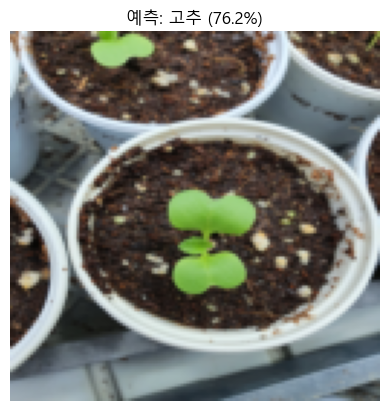

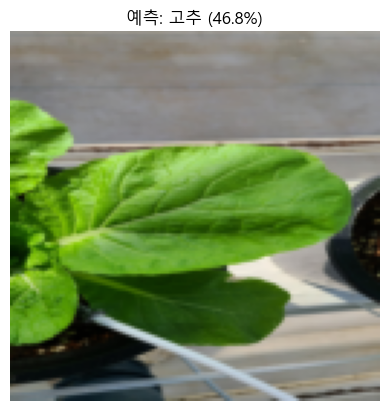

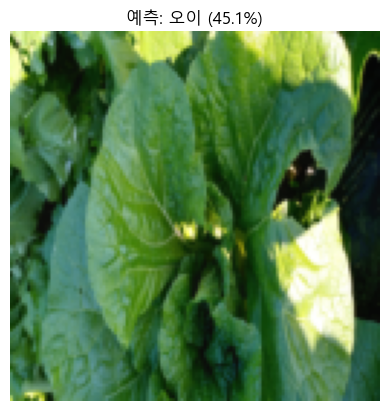

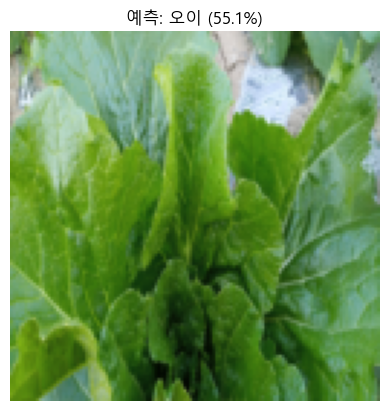

('오이', np.float32(55.074482))

In [ ]:
predict_image(os.path.join(cabbage_folder, target_files[0]), loaded_model)
predict_image(os.path.join(cabbage_folder, target_files[6]), loaded_model)
predict_image(os.path.join(cabbage_folder, target_files[13]), loaded_model)
predict_image(os.path.join(cabbage_folder, target_files[20]), loaded_model)

## 예측 파이프라인 점검 및 오분류 확인

초기 예측 테스트에서 배추 이미지가 다른 클래스로 예측되는 사례가 반복되어
예측 함수의 전처리 과정을 점검함.

- 예측 함수에서 사용하는 이미지 로딩 및 resize 방식을
  학습/평가 과정과 최대한 일관되게 맞추기 위해
  `keras.utils.load_img(..., interpolation='bilinear')` 방식으로 수정함

- 전처리 방식을 통일한 뒤 다시 예측한 결과,
  일부 배추 이미지는 정상적으로 분류되지 않고
  오이 또는 고추로 예측되는 사례가 계속 확인됨

- 따라서 초기 오분류 현상을 전처리 차이만으로 설명하기는 어려웠으며,
  최종 모델 자체에서도 클래스 간 특징을 구분하지 못하는 사례가 존재함을 확인함

- 결론:
  실제 추론 단계에서는 학습·평가와 동일한 전처리 흐름을 유지하는 것이 중요하지만,
  전처리 통일만으로 모든 오분류가 해결되지는 않았음.
  이후 Confusion Matrix 및 클래스별 지표를 통해 모델 자체의 오분류 패턴을 추가로 분석함

==================================================================================================

In [ ]:
from tensorflow import keras

# 1. 저장된 최종 모델 불러오기
model = keras.models.load_model(
    r"C:\Users\AISW_203_103\Desktop\crop-classifier\model\crop_classifier_final_600.keras"
)

print("모델 불러오기 완료")

모델 불러오기 완료


In [ ]:
IMG_SIZE = 128
BATCH_SIZE = 32

val_ds = keras.utils.image_dataset_from_directory(
    r"C:\Users\AISW_203_103\Desktop\crop-classifier\data\reprocessed\val",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

Found 450 files belonging to 3 classes.


In [ ]:
val_loss, val_accuracy = model.evaluate(val_ds, verbose=1)

print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Validation Loss: {val_loss:.4f}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 294ms/step - accuracy: 0.8644 - loss: 0.3261
Validation Accuracy: 0.8644
Validation Loss: 0.3261


In [ ]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

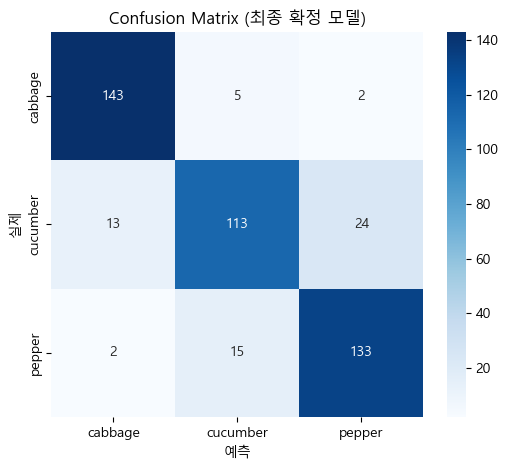

              precision    recall  f1-score   support

     cabbage       0.91      0.95      0.93       150
    cucumber       0.85      0.75      0.80       150
      pepper       0.84      0.89      0.86       150

    accuracy                           0.86       450
   macro avg       0.86      0.86      0.86       450
weighted avg       0.86      0.86      0.86       450



In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

y_true = []
y_pred = []

for images, labels in val_ds:
    # 저장된 최종 모델로 예측
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

cm = confusion_matrix(y_true, y_pred)

class_names_list = ['cabbage', 'cucumber', 'pepper']

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_names_list,
    yticklabels=class_names_list,
    cmap='Blues'
)

plt.xlabel('예측')
plt.ylabel('실제')
plt.title('Confusion Matrix (최종 확정 모델)')
plt.show()

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names_list
    )
)

# 전체 실험 결론

이번 프로젝트에서는 고추·배추·오이 3개 클래스를 분류하는 CNN 모델을 구현하고,
과적합 문제를 시작으로 모델 구조와 데이터 구성에 따른 성능 변화를 단계적으로 확인함.

## 1. Baseline에서 과적합 확인

초기 CNN 모델은 학습이 진행될수록 Train Accuracy가 크게 상승했지만,
Validation Accuracy는 60%대에 머물고 Validation Loss가 증가함.

- Baseline 최종 Train Accuracy: 99.94%
- Baseline 최종 Validation Accuracy: 66.67%
- Baseline 최종 Validation Loss: 2.5658

Train과 Validation 성능의 차이를 통해 과적합이 발생하고 있다고 판단함.


## 2. 정규화 기법 적용

과적합을 완화하기 위해 Data Augmentation과 Dropout 비율 변경을 적용함.

- Data Augmentation만 적용했을 때 Validation 성능은 개선되지 않음
- Dropout을 0.3에서 0.5로 증가했을 때 일부 개선이 나타남
- Data Augmentation과 Dropout 0.5를 함께 적용한 경우 Validation 성능이 오히려 하락함

따라서 정규화 기법을 추가하는 것만으로는 기존 모델의 과적합 문제를 충분히 해결하지 못함.


## 3. 모델 구조 단순화

초기 모델이 현재 데이터 규모에 비해 복잡할 가능성을 고려하여
Filter와 Dense Layer의 크기를 줄이고 Flatten을 Global Average Pooling(GAP)으로 변경함.

- Baseline 파라미터: 859,395개
- 실험 5 파라미터: 15,491개
- 실험 7 파라미터: 5,411개

모델을 단순화하면서 파라미터 수와 Train-Validation 성능 격차,
Validation Loss가 감소하는 결과를 확인함.

하지만 모델 구조를 변경한 이후에도 Validation Accuracy가 60%대에 머물러
모델 구조 외의 요인도 확인할 필요가 있다고 판단함.


## 4. Training / Validation 데이터 구성 확인 및 재분배

원본 Training과 Validation 이미지를 직접 샘플링하여 비교한 결과,
동일 클래스에서도 피사체와 생육 단계의 차이가 관찰됨.

- 고추: Training에서는 열매 중심, Validation에서는 잎·줄기·꽃이 포함된 이미지가 관찰됨
- 배추: 어린 묘와 성장한 배추 등 생육 단계의 차이가 관찰됨
- 오이: Training에서는 열매 중심, Validation에서는 꽃·잎이 포함된 이미지가 관찰됨

샘플 이미지에서 관찰한 차이만으로 데이터 분할이 성능 저하의 원인이라고 단정하지 않고,
기존 Training과 Validation 데이터를 통합한 뒤 무작위로 재분배하여 동일한 모델 구조로 다시 비교함.

재분배 전후 동일한 실험 5 모델을 비교한 결과:

- Validation Accuracy: 65.11% → 79.78%
- Validation Loss: 1.0065 → 0.4490
- Train-Validation Accuracy 격차: 26.89%p → 1.33%p

데이터 구성을 변경한 조건에서 Validation 성능이 크게 개선됨을 확인함.


## 5. 최종 모델 선택

재분배 데이터를 기준으로 학습 Epoch을 늘려 추가 실험을 진행하고,
더 작은 모델과도 비교함.

최종적으로 실험 10의 Keras CNN을 최종 모델로 선택함.

- 구조: Conv 16-32-32 → GAP → Dense 32 → Dropout 0.5
- 총 파라미터: 15,491개
- 실제 학습 Epoch: 50
- Train Accuracy: 87.22%
- Validation Accuracy: 86.44%
- Train Loss: 0.3048
- Validation Loss: 0.3261

추가 단순화한 실험 11에서는 파라미터를 5,411개까지 줄였지만
Validation Accuracy가 82.67%로 감소하고 Validation Loss가 0.4246으로 증가함.

따라서 가장 작은 모델을 선택하기보다,
이번 실험에서 성능과 모델 복잡도의 균형이 더 좋았던 실험 10을 최종 모델로 선택함.


## 6. 최종 모델 학습 과정

최종 모델에서는 Train Accuracy와 Validation Accuracy가 학습이 진행될수록
전반적으로 함께 상승했고, Train Loss와 Validation Loss도 전체적으로 감소함.

- 학습 중 최고 Validation Accuracy: 87.33% (Epoch 49)
- 최저 Validation Loss: 0.3261 (Epoch 50)
- 최종 복원 모델 Train Accuracy: 87.22%
- 최종 복원 모델 Validation Accuracy: 86.44%

EarlyStopping은 Validation Loss를 기준으로 설정했지만,
학습 후반까지 Validation Loss가 갱신되어 최대 설정값인 50 Epoch까지 학습이 진행됨.

초기 Baseline에서 나타났던 큰 Train-Validation 성능 격차가
최종 모델에서는 크게 감소함.


## 7. 클래스별 성능 및 오분류 분석

최종 Validation 데이터 450장을 평가한 결과 전체 389장을 올바르게 분류하여
Validation Accuracy 86.44%를 기록함.

| Class | Precision | Recall | F1-score | Support |
|---|---:|---:|---:|---:|
| cabbage | 0.91 | 0.95 | 0.93 | 150 |
| cucumber | 0.85 | 0.75 | 0.80 | 150 |
| pepper | 0.84 | 0.89 | 0.86 | 150 |

cabbage는 Recall 0.95로 가장 높은 성능을 보였고,
cucumber는 Recall 0.75로 세 클래스 중 가장 낮게 나타남.

Confusion Matrix에서는 cucumber → pepper 오분류가 24건으로 가장 많았고,
pepper → cucumber도 15건 발생하여 두 클래스 사이의 혼동이 상대적으로 크게 나타남.

별도의 실제 이미지 예측 과정에서도 정답과 다른 클래스로 예측되는 사례가 확인되어,
전체 Validation Accuracy만으로는 확인하기 어려운 개별 이미지 수준의 실패 사례도 존재함을 확인함.


## 최종 결론

초기에는 과적합 문제를 모델의 정규화와 구조 변경을 중심으로 개선하려 했지만,
모델을 단순화한 이후에도 Validation 성능의 한계가 지속됨.

이후 실제 데이터를 직접 확인하면서 모델 구조뿐 아니라
Training / Validation 데이터 구성도 성능에 영향을 줄 수 있는 요소로 보고 재검증함.

데이터 재분배 이후 동일한 모델에서 Validation 성능이 크게 개선되었고,
추가 학습과 모델 복잡도 비교를 통해 최종 CNN 모델을 선택함.

최종 모델은 Validation Accuracy 86.44%를 기록했지만,
클래스별 분석에서는 cucumber의 Recall이 상대적으로 낮고
cucumber와 pepper 사이의 오분류가 많이 발생하는 한계도 확인됨.

이번 실험을 통해 이미지 분류 모델의 성능을 개선할 때
모델 구조와 하이퍼파라미터뿐 아니라 데이터 구성과 분할 상태를 함께 확인해야 하며,
최종 Accuracy뿐 아니라 학습 곡선, Validation Loss, 클래스별 지표,
Confusion Matrix와 실제 오분류 사례를 함께 분석하는 과정이 중요함을 확인함.